<a href="https://colab.research.google.com/github/inmira/Crypto-Market-Microstructure-Volatility-Analysis/blob/main/Crypto_Market_Microstructure_%26_Volatility_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*The goal of this project is to analyze the statistical behavior of the BTC/USDT cryptocurrency market using historical Binance data.*

#Imports&Data Loading

In [1]:
!pip install python-binance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.5/148.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 58.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from binance.client import Client
from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import adfuller

pd.set_option('display.max_columns', None)

In [3]:
client = Client()

In [4]:
klines = client.get_historical_klines(
    "BTCUSDT",
    Client.KLINE_INTERVAL_1HOUR,
    "12 months ago UTC"
)

In [5]:
columns = [
    'open_time',
    'open',
    'high',
    'low',
    'close',
    'volume',
    'close_time',
    'quote_asset_volume',
    'number_of_trades',
    'taker_buy_base_asset_volume',
    'taker_buy_quote_asset_volume',
    'ignore'
]

df = pd.DataFrame(klines, columns=columns)

In [6]:
df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')

numeric_cols = ['open', 'high', 'low', 'close', 'volume']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df = df[['open_time', 'open', 'high', 'low', 'close', 'volume']]

df.head()

,open_time,open,high,low,close,volume
0,2025-05-07 09:00:00,97024.46,97059.70,96876.00,96978.40,341.26007
1,2025-05-07 10:00:00,96978.40,97111.00,96833.33,97030.01,296.12240
2,2025-05-07 11:00:00,97030.01,97070.06,96929.17,97047.43,256.14738
3,2025-05-07 12:00:00,97047.43,97200.00,96870.35,96966.08,531.66176
4,2025-05-07 13:00:00,96966.07,97316.03,96713.14,97022.01,829.46434


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   open_time  8760 non-null   datetime64[ns]
 1   open       8760 non-null   float64       
 2   high       8760 non-null   float64       
 3   low        8760 non-null   float64       
 4   close      8760 non-null   float64       
 5   volume     8760 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 410.8 KB


#Log Returns&Volatility

In [8]:
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

In [9]:
df = df.dropna()

In [10]:
df['log_return'].describe()

,log_return
count,8759.000000
mean,-0.000020
std,0.004457
min,-0.037894
25%,-0.001924
50%,0.000020
75%,0.001973
max,0.034139


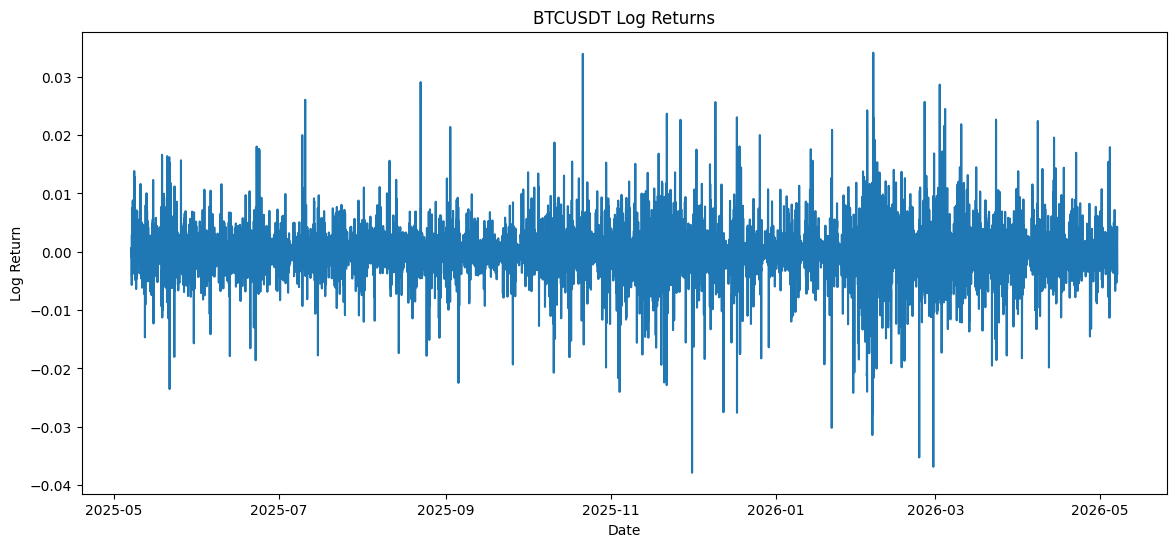

In [11]:
plt.figure(figsize=(14,6))
plt.plot(df['open_time'], df['log_return'])

plt.title('BTCUSDT Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')

plt.show()

In [12]:
df['rolling_volatility'] = (
    df['log_return']
    .rolling(window=24)
    .std()
)

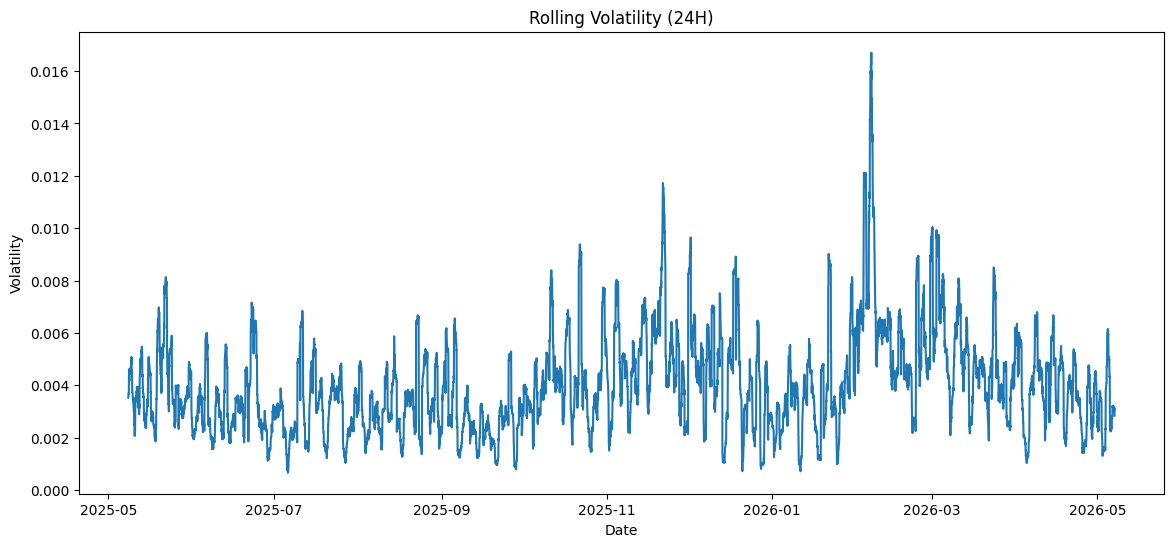

In [13]:
plt.figure(figsize=(14,6))

plt.plot(
    df['open_time'],
    df['rolling_volatility']
)

plt.title('Rolling Volatility (24H)')
plt.xlabel('Date')
plt.ylabel('Volatility')

plt.show()

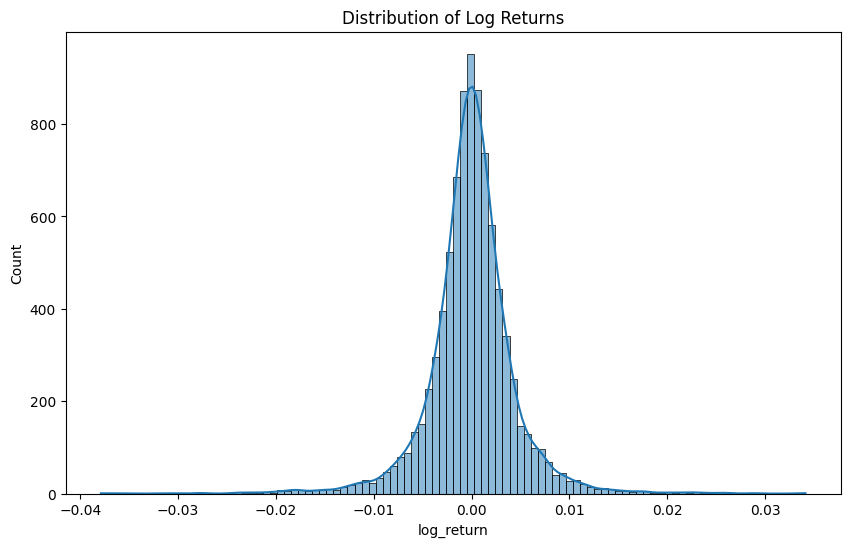

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['log_return'],
    bins=100,
    kde=True
)

plt.title('Distribution of Log Returns')

plt.show()

In [15]:
print("Skewness:", skew(df['log_return']))
print("Kurtosis:", kurtosis(df['log_return']))

Skewness: -0.25243087503522993
Kurtosis: 7.849070462777156


BTC returns demonstrated significant excess kurtosis, indicating fat-tailed behavior and elevated probability of extreme market moves compared to a normal distribution.

#Market Regime Detection

In [16]:
df = df.dropna()

In [17]:
low_threshold = df['rolling_volatility'].quantile(0.25)
high_threshold = df['rolling_volatility'].quantile(0.75)

print(low_threshold)
print(high_threshold)

0.002654456889437103
0.004954614154005171


In [18]:
def classify_regime(vol):

    if vol <= low_threshold:
        return 'Low Volatility'

    elif vol >= high_threshold:
        return 'High Volatility'

    else:
        return 'Medium Volatility'


df['regime'] = df['rolling_volatility'].apply(classify_regime)

In [19]:
df['regime'].value_counts()

,count
regime,
Medium Volatility,4368
High Volatility,2184
Low Volatility,2184


In [20]:
regime_map = {
    'Low Volatility': 0,
    'Medium Volatility': 1,
    'High Volatility': 2
}

df['regime_numeric'] = df['regime'].map(regime_map)

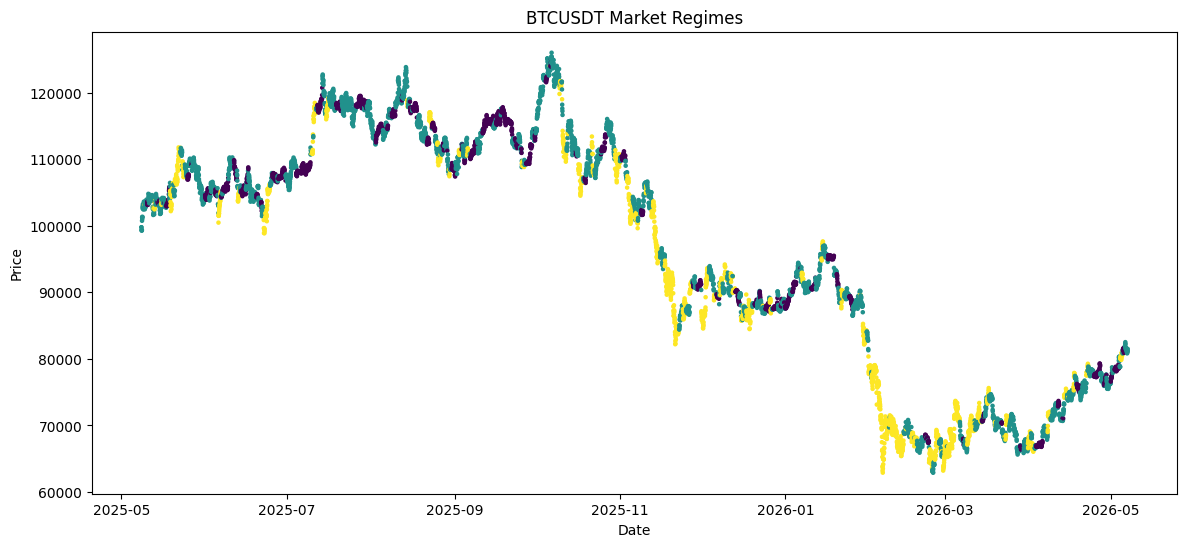

In [21]:
plt.figure(figsize=(14,6))

scatter = plt.scatter(
    df['open_time'],
    df['close'],
    c=df['regime_numeric'],
    s=5
)

plt.title('BTCUSDT Market Regimes')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

#Volume vs Volatility

In [22]:
correlation = df['volume'].corr(df['rolling_volatility'])

print("Correlation:", correlation)

Correlation: 0.4255963379139003


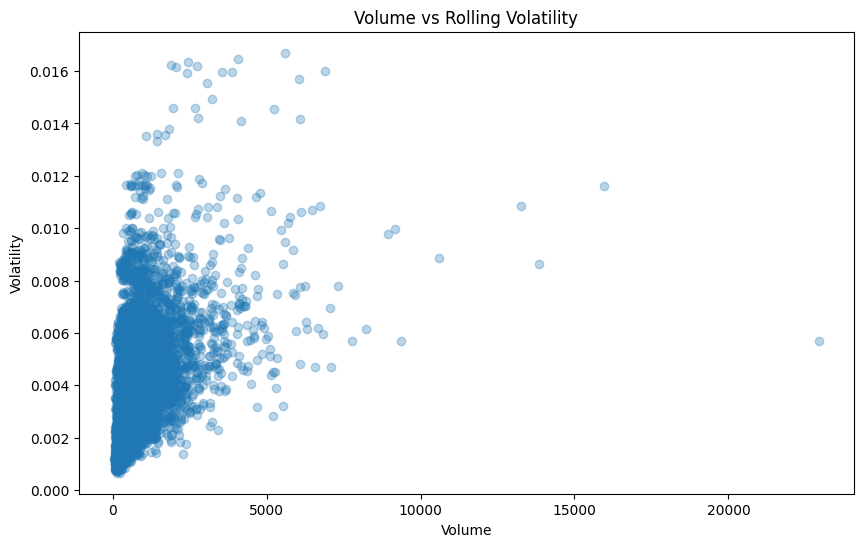

In [23]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['volume'],
    df['rolling_volatility'],
    alpha=0.3
)

plt.title('Volume vs Rolling Volatility')
plt.xlabel('Volume')
plt.ylabel('Volatility')

plt.show()

#ADF Stationarity Test

In [24]:
adf_result = adfuller(df['log_return'])

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

ADF Statistic: -92.95908709298423
p-value: 0.0


# Conclusions

## Market Behavior Analysis

The analysis of BTC/USDT hourly returns showed several characteristics commonly observed in financial markets:

- Returns were centered close to zero, indicating limited directional predictability over short horizons.
- The return distribution exhibited negative skewness and high kurtosis (~7.85), suggesting fat-tailed behavior and increased probability of extreme market moves compared to a normal distribution.
- These results highlight the noisy and highly dynamic nature of crypto markets.

## Volatility Dynamics

Rolling volatility analysis revealed clear volatility clustering, where periods of elevated volatility persisted over time rather than occurring randomly.

Using volatility quantiles, the market was classified into low, medium, and high volatility regimes. High-volatility regimes were associated with more unstable market conditions and stronger price fluctuations.

This behavior is consistent with regime-dependent dynamics frequently observed in financial and crypto markets.

## Statistical Relationships

The analysis identified a positive relationship between trading volume and volatility (correlation ≈ 0.43), indicating that market activity tends to increase during periods of elevated uncertainty.

Additionally, the Augmented Dickey-Fuller (ADF) test confirmed that log returns are stationary (p-value < 0.05), making them more suitable for statistical modeling and quantitative analysis than raw prices.

These findings support the use of statistical and time-series methods for studying crypto market behavior.